This folder is sandboxed from the rest of the emulator, intended to test final emulator predictions using exact parameters.

In [3]:
saved_seds = []

In [9]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

from tardis.io.configuration.config_reader import Configuration
from tardis.simulation import Simulation
from tardis.io.atom_data.base import AtomData
from grid_run.make_csvy import make_csvy, make_abundances
import astropy.constants as c
import astropy.units as u

os.environ['OMP_NUM_THREADS'] = '4'
os.environ['MKL_NUM_THREADS'] = '4'
os.environ['NUMEXPR_NUM_THREADS'] = '4'

log_lsun = 8.6
t_exp = 13.6 * u.day
v_start = 6078.699940 * u.km/u.s
n = 12
X = 0.75
Z = 0.001777
log_scale = 52.105895

# Run simulation
sandbox_dir = os.path.abspath('.')
make_csvy(
    v_start,
    v_stop=v_start*3,
    shells=10,
    n=n,
    csvy_path=os.path.join(sandbox_dir, 'model.csvy'),
    abundances=make_abundances(X, Z)
)
atomic = AtomData.from_hdf(os.path.join(sandbox_dir, 'atom_data.h5'))
config = Configuration.from_yaml(os.path.join(sandbox_dir, 'config.yml'))
config.supernova.luminosity_requested = 10**log_lsun * c.L_sun
config.supernova.time_explosion = t_exp

sim = Simulation.from_config(
    config,
    atom_data = atomic,
    virtual_packet_logging=False,
    show_convergence_plots=False,
    export_convergence_plots=False,
    log_level='DEBUG'
)
sim.run_convergence()
sim.run_final()

Zeta_data missing - replaced with 1s. Missing ions: [(12, 13), (14, 15), (16, 17), (26, 27)]
Zeta_data missing - replaced with 1s. Missing ions: [(12, 13), (14, 15), (16, 17), (26, 27)]


TqdmHBox(children=(HTML(value='Packets:\u2007\u2007\u2007', layout=Layout(width='6%')), FloatProgress(value=0.…

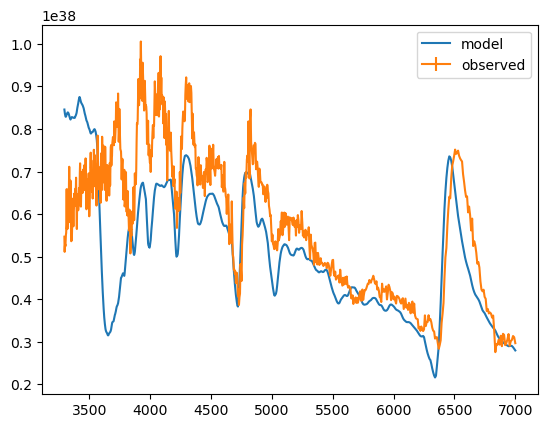

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

y_mod = sim.spectrum_solver.spectrum_integrated.luminosity_density_lambda.value
wav = sim.spectrum_solver.spectrum_integrated.wavelength.value

# Get observed data
scale = 10**log_scale
from scipy.interpolate import interp1d
obs_df = pd.read_csv(r'/home/mikel/GitHub/iip-emulator/interpolator/calibrated_spectra/2020jfo-2020-05-19.csv', comment='#')
y_obs = interp1d(obs_df['wavelength'], obs_df['flux'], bounds_error=False)(wav)
y_obs_err = interp1d(obs_df['wavelength'], obs_df['fluxerr'], bounds_error=False)(wav)

mask = ~np.isnan(y_obs)
wav = wav[mask]
y_obs = y_obs[mask]
y_mod = y_mod[mask]
y_obs_err = y_obs_err[mask]

plt.plot(wav, y_mod, label='model')
plt.errorbar(wav, y_obs*scale, yerr=np.abs(y_obs_err)*scale, label='observed')
plt.legend()
plt.show()

In [10]:
saved_seds.append(sim.spectrum_solver.spectrum_integrated.luminosity_density_lambda.value)

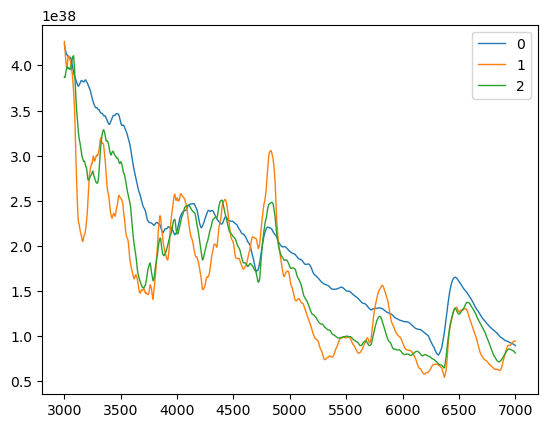

In [11]:
# Display all saved
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

wav = sim.spectrum_solver.spectrum_integrated.wavelength.value

i = 0
for y_mod in saved_seds:
    plt.plot(wav, y_mod, lw=1, label=i)
    i += 1
plt.legend()
plt.show()

[ 5200.          5475.52943498  5826.97533949  6275.2549355
  6847.04875532  7576.38860323  8506.68304734  9693.30099399
 11206.86711303 13137.46524964 15600.        ]


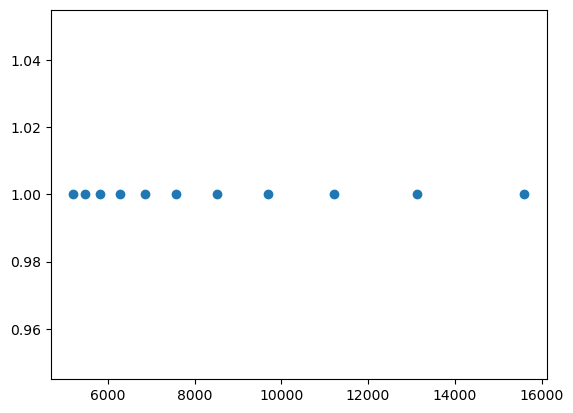

In [26]:
log_start = 3
start = 5200
stop = start * 3
shells = 10
v = (np.logspace(log_start, np.log10(stop-start+10**log_start), num=shells+1) + start - 10**log_start)
print(v)
plt.scatter(v, np.ones_like(v))
plt.show()

In [ ]:
for y_mod in saved_seds:
    y_mod = y_mod[mask]

    # Find best fit scale
    def f(x):
        scale = x[0]
        y1 = y_mod
        y2 = y_obs*scale
        fe = np.abs(y1 - y2)/y2
        mean_fe = np.mean(fe)
        mse = np.mean((y1-y2)**2)
        return mse

    from scipy.optimize import differential_evolution
    scale_guess = np.max(y_mod) / np.max(y_obs)
    result = differential_evolution(f, x0=[scale_guess], bounds=[(10**50, 10**60)])
    scale = result.x[0]
    distance = np.sqrt(scale/4/np.pi) * u.cm
    print('scale guess:', scale_guess)
    print('scale:', scale)
    print('distance:', distance.to(u.Mpc))

    plt.plot(wav, y_mod, label='model')
    plt.plot(wav, y_obs*scale, label='observed')
    plt.legend()
    plt.show()

In [ ]:
#print(sim.plasma.plasma_properties_dict.keys())
print(sim.plasma.dilute_planckian_radiation_field.temperature_kelvin)
print(sim.converged)
print(sim.iterations_executed)
print(sim.iterations_t_inner)